## Inter-Subject Representational Similarity Analysis - All Movie Scenes (Revision)

*This script was used to perform the IS-RSA analysis with data from all movie scenes in the main sample. It includes a) installation of the relevant software and packages, b) conversion of the fMRI data c) trimming of timecourses, d) assessment of brain similarity, e) assessment of trait similarity and f) computation of brain-trait representational similarity on whole-brain, network- and region-specific level.* 

### 1. Software Installation - Create environment (anaconda prompt)

**Create an environment with the correct software versions in the anaconda prompt**   

conda config --add channels conda-forge  
conda config --set channel_priority strict

**Create a new environment** 

conda create -n ISRSAenv python=3.10 #*create environment*  
conda activate ISRSAenv #*activate environment*  
conda install numpy=1.23.5 #*install numpy*  
conda install ipykernel #*install ipykernel in the environment to make environment accessible as a Jupyter Kernel*  
python -m ipykernel install --user --name=ISRSAenv --display-name "Python (ISRSAenv)" #*registern as a kernel*   
pip install nltools #*install nltools*   
python -c "import nltools; print(nltools.__version__)" #*verify installation*  

**Install packages in the anaconda prompt**  

conda install scipy scikit-learn pandas matplotlib seaborn  
conda install -c defaults -c conda-forge brainiak
pip install nibabel datalad nilearn nltools hypertools timecorr pliers statesegmentation networkx nltk requests urllib3
pip install git+https://github.com/FIU-Neuro/brainconn#egg=brainconn

### 2. Load stuff

In [1]:
import sys
print(sys.version) #check which python version is used

3.11.11 | packaged by conda-forge | (main, Dec  5 2024, 14:06:23) [MSC v.1942 64 bit (AMD64)]


In [3]:
import os
import glob
from pathlib import Path

import numpy as np
from scipy.stats import rankdata, ttest_rel, ttest_1samp

from matplotlib import pyplot as plt
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms

import pandas as pd
import seaborn as sns

import nibabel as nib
from nilearn.input_data import NiftiLabelsMasker
from nilearn.plotting import plot_glass_brain, plot_stat_map, view_img, view_img_on_surf

from sklearn.metrics import pairwise_distances
from sklearn.utils import check_random_state
from sklearn.manifold import TSNE

%matplotlib inline

from nltools.data import Brain_Data, Adjacency
from nltools.mask import roi_to_brain, expand_mask
from nltools.stats import fdr, threshold

### 3. Get fMRI timecourses (only need to run this part once!)

*Change to desired directory*

In [5]:
import os 
print(os.getcwd())

os.chdir(r'E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP')
print(os.getcwd())

C:\Users\jop86ib\Documents\Paper 4\Code
E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP


*Convert nifti files in folder into csv files*

In [18]:
import os
import gzip
import shutil
import nibabel as nib
import pandas as pd

# Assign base directory
base_dir = r'E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP'

# Define target folders
target_folders = [
    "tfMRI_MOVIE1_7T_AP",
    "tfMRI_MOVIE2_7T_PA",
    "tfMRI_MOVIE3_7T_PA",
    "tfMRI_MOVIE4_7T_AP"
]

# Function to extract .nii.gz files
def extract_gz(nifti_gz_file):
    """Extract a .nii.gz file and save as .nii in the same folder."""
    extracted_file = nifti_gz_file[:-3]  # Remove the .gz extension
    with gzip.open(nifti_gz_file, 'rb') as f_in:
        with open(extracted_file, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    return extracted_file

# Iterate through all subject folders
for subject_folder in os.listdir(base_dir):
    subject_path = os.path.join(base_dir, subject_folder)

    # Ensure it's a directory
    if not os.path.isdir(subject_path):
        continue

    print(f"Processing subject: {subject_folder}")
    
    # Iterate through the four target folders
    for target_folder in target_folders:
        folder_path = os.path.join(subject_path, target_folder)
        nifti_gz_file = os.path.join(folder_path, "yan200.ptseries.nii.gz")
        nifti_file = os.path.join(folder_path, "yan200.ptseries.nii")
        csv_file = os.path.join(folder_path, "yan200.ptseries.csv")

        # Step 1: Extract the .nii.gz file if it exists
        if os.path.exists(nifti_gz_file):
            print(f"Extracting: {nifti_gz_file}")
            extracted_file = extract_gz(nifti_gz_file)
            print(f"Saved extracted file: {extracted_file}")
        else:
            print(f" Did not find .gz file: {nifti_gz_file}")
            continue  # Skip to next folder if .gz file is missing

        # Step 2: Convert NIfTI to CSV
        if os.path.exists(nifti_file):
            print(f"Processing NIfTI file: {nifti_file}")
            nifti_img = nib.load(nifti_file)
            data = nifti_img.get_fdata()  # Extract data

            # Ensure it's a 2D file, otherwise skip
            if data.ndim != 2:
                print(f"Skipping {nifti_file} because it has more than 2 dimensions: {data.shape}")
                continue

            # Convert to Pandas DataFrame
            df = pd.DataFrame(data)
            df.columns = [f"Node_{i}" for i in range(df.shape[1])]

            # Save as CSV
            df.to_csv(csv_file, index=False)
            print(f"Saved CSV file: {csv_file}")
        else:
            print(f"Did not find extracted NIfTI file: {nifti_file}")

print("All files processed successfully!")


Processing subject: 573249
Extracting: E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP\573249\tfMRI_MOVIE1_7T_AP\yan200.ptseries.nii.gz
Saved extracted file: E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP\573249\tfMRI_MOVIE1_7T_AP\yan200.ptseries.nii
Processing NIfTI file: E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP\573249\tfMRI_MOVIE1_7T_AP\yan200.ptseries.nii
Saved CSV file: E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP\573249\tfMRI_MOVIE1_7T_AP\yan200.ptseries.csv
Extracting: E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP\573249\tfMRI_MOVIE2_7T_PA\yan200.ptseries.nii.gz
Saved extracted file: E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP\573249\tfMRI_MOVIE2_7T_PA\yan200.ptseries.nii
Processing NIfTI file: E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP\573249\tfMRI_MOVIE2_7T_PA\yan200.ptseries.nii
Saved CSV file: E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_F

*Check whether files were saved correctly (Subject 102311)*

In [5]:
#load data 
nifti_path = r'E:\Data\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP\102311\tfMRI_MOVIE3_7T_PA\yan200.ptseries.nii'  # Original NIfTI-Datei
csv_path = r'E:\Data\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP\102311\tfMRI_MOVIE3_7T_PA\yan200.ptseries.csv'    # Umgewandelte CSV-Datei

nifti_img = nib.load(nifti_path)
nifti_data = nifti_img.get_fdata()

csv_data = pd.read_csv(csv_path).to_numpy()

# check whether data shape matches
print("NIfTI Shape:", nifti_data.shape)
print("CSV Shape:  ", csv_data.shape)


NIfTI Shape: (915, 200)
CSV Shape:   (915, 200)


In [7]:
# Check whether values are exactly the same
if np.allclose(nifti_data, csv_data, atol=1e-6):
    print("Data in csv file and nifti file match exactly!")
else:
    print("Data in csv file and nifti file differ!")

Data in csv file and nifti file match exactly!


### 4. Put fMRI timecourses in correct format

In [9]:
HCP_behavioral_movie_main_89 = pd.read_csv(r'E:\Data\Data Project 4\Behavioral Data HCP\HCP_behavioral_movie_main_89.csv')

subj_list = HCP_behavioral_movie_main_89['Subject'].astype(str)
data_dir = r'E:\Data\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP'
print(subj_list)

0     100610
1     102311
2     102816
3     104416
4     105923
       ...  
84    690152
85    725751
86    757764
87    789373
88    878776
Name: Subject, Length: 89, dtype: object


*Select timepoints relevant for the analyses (Here --> all timepoints)*

*Relevant Movie Data (ALL --> Movie Scenes+ discard first 10 TR from each clip and include 5 TR immediately following offset of each clip!)* 

#### Movie 1  
Clip 1: [30 - 237]  
Clip 2: [294 - 510]  
Clip 3: [535 - 711]  
Clip 4: [743 - 802]  
Clip 5: [827 - 906]  

#### Movie 2: 
Clip 1: [30 - 252]  
Clip 2: [277 - 530]  
Clip 3: [555 - 799]  
Clip 4: [824 - 903]  

#### Movie 3: 
Clip 1: [30 - 205]  
Clip 2: [230 - 410]  
Clip 3: [435 - 634]  
Clip 4: [659 - 796]  
Clip 5: [821 - 900]  

#### Movie 4:   
Clip 1: [30 - 257]  
Clip 2: [282 - 507]  
Clip 3: [532 - 782]  
Clip 4: [807 - 886]  

*BUT: keep in mind that I need to subtract 1 from these indices, as the indexing in python starts with 0, not with 1!* 

*Load data and stack them into a 3d array (subjects x TR x nodes)*

*Loads in the movie data from all four movies (all scenes) --> compile complete data here (z-score before compiling data)*

In [11]:
data = []
clip_ranges = {  # Define the row ranges for each movie (adjusted for Python's 0-based indexing)
    "tfMRI_MOVIE1_7T_AP": [(29, 236), (293, 509), (534, 710), (742, 801), (826, 905)],
    "tfMRI_MOVIE2_7T_PA": [(29, 251), (276, 529), (554, 798), (823, 902)],
    "tfMRI_MOVIE3_7T_PA": [(29, 204), (229, 409), (434, 633), (658, 795), (820, 899)],
    "tfMRI_MOVIE4_7T_AP": [(29, 256), (281, 506), (531, 781), (806, 885)]
}

for subj in subj_list:
    sub_data = []
    
    # Iterate over the folder names (which are the keys in the clip_ranges dictionary)
    for folder in clip_ranges.keys():
        file_path = os.path.join(data_dir, subj, folder, 'yan200.ptseries.csv')
        
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)

            # Z-score normalization (column-wise)
            df_zscored = (df - df.mean()) / df.std(ddof=0)

            # Select only the relevant rows based on the given ranges (adjusted for 0-based indexing)
            selected_rows = [df_zscored.iloc[start:end] for start, end in clip_ranges[folder]]
            df_filtered = pd.concat(selected_rows, ignore_index=True)  # Resets index
            
            sub_data.append(df_filtered)  # Append filtered data for this subject
        else:
            print(f"Warning: File not found for {subj} in {folder}")

    if sub_data:
        sub_data = pd.concat(sub_data, ignore_index=True)  # Combine dataframes if data was loaded
        data.append(sub_data.values)  # Store as NumPy array

# Final array with all subjects' data
data = np.array(data)

In [13]:
data.shape #looking good, this is the number I get when adding up the lengths of the scenes above!

(89, 3086, 200)

In [15]:
n_subs, n_ts, n_nodes = data.shape

*Check values --> has z-scoring worked?*

In [17]:
# Looks like the data import from the csv files has worked properly

import numpy as np

# Check if data was loaded properly
if len(data) > 0:
    subj_1_data = data[0]  # First subject
    if subj_1_data.shape[1] > 0:  # Ensure there is at least one column
        print(subj_1_data[:, 0])  # Print first column
    else:
        print("Subject 1 data is empty or does not have a first column.")
else:
    print("Data array is empty.")


[ 0.02700602 -0.95400463 -1.14638784 ... -0.01463092 -0.07925364
  0.37199821]


In [19]:
data[0].shape

(3086, 200)

### 5. Calculate brain similarity

Calculate one ISC matrix (dimension subject by subject) for each of the 200 nodes 
--> pairwise distances: computes distance matrix: similarity: 1-correlation
--> similarity matrices are stored in nltools.data.Adjacency instance

In [21]:
similarity_matrices = []
for node in range(n_nodes):
    similarity_matrices.append(Adjacency(1 - pairwise_distances(data[:, :, node], metric='correlation'), matrix_type='similarity'))
similarity_matrices = Adjacency(similarity_matrices)

In [23]:
global_min = min(mat.data.min() for mat in similarity_matrices)
global_max = max(mat.data.max() for mat in similarity_matrices)

In [25]:
print(f"Global Min: {global_min}")
print(f"Global Max: {global_max}")

Global Min: -0.16281290240410917
Global Max: 0.737986344128711


*Check data format*

In [27]:
print(type(similarity_matrices.data))
print(similarity_matrices.data.shape)  # Shape of NumPy-Array
print(similarity_matrices.data[:10])  # Shows first couple of values

<class 'numpy.ndarray'>
(200, 3916)
[[0.20566674 0.10567487 0.25265871 ... 0.24806009 0.16965509 0.20151186]
 [0.28015046 0.20591247 0.31527369 ... 0.08757214 0.22104251 0.22015055]
 [0.50968864 0.30145267 0.49575771 ... 0.42959549 0.50385778 0.38127059]
 ...
 [0.19395901 0.09095533 0.15744556 ... 0.23469572 0.30206933 0.23813108]
 [0.21188312 0.07202111 0.03449651 ... 0.03505955 0.07571739 0.1259783 ]
 [0.19273506 0.02928764 0.11974423 ... 0.12810276 0.14236721 0.07960232]]


*Plot distribution of all correlation coefficients in the matrices*

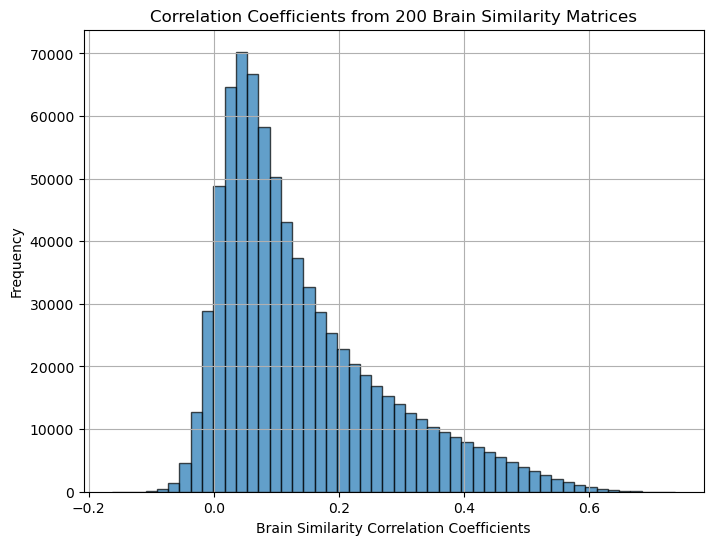

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Convert values from 2D aray into 1D array 
all_values = similarity_matrices.data.flatten()

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(all_values, bins=50, color='C0', alpha=0.7, edgecolor='black')
plt.xlabel('Brain Similarity Correlation Coefficients')
plt.ylabel('Frequency')
plt.title('Correlation Coefficients from 200 Brain Similarity Matrices')
plt.grid(True)

# Did not need to save the Figure again (for Revision) ...

# Save figure 
# file_path_figure = r'C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\Distribution_IS-RSA_Correlation_Coefficients_All_Scenes.png'
# plt.savefig(file_path_figure, dpi=300, bbox_inches="tight")

# plt.show()

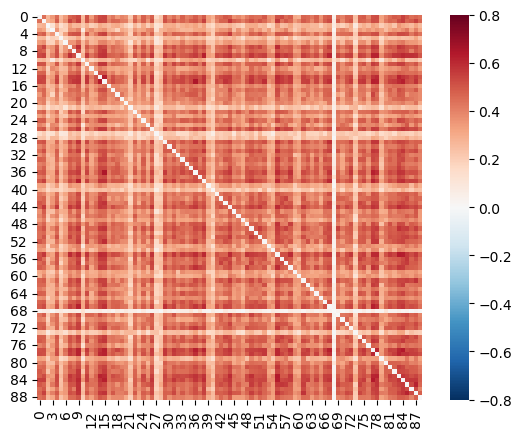

In [33]:
similarity_matrices[193].plot(vmin=-0.8, vmax=0.8, cmap='RdBu_r')

We want to see which nodes show the highest ISC across the whole group --> Adjacency.isc is used to compute the mean (or median) of the lower triangle of the matrix using Adjacency.isc method 

In [35]:
isc = {node:similarity_matrices[node].isc(metric='mean', n_jobs=1)['isc'] for node in range(n_nodes)}

In [37]:
print(isc)

{0: 0.20494752726486704, 1: 0.201127056979933, 2: 0.3994763542331866, 3: 0.17935296064963263, 4: 0.2186588704394806, 5: 0.15053669197623082, 6: 0.10541502746180408, 7: 0.1460038802116255, 8: 0.09378885486304506, 9: 0.10625701274799151, 10: 0.11327735848255618, 11: 0.1302433612284612, 12: 0.09495542684760647, 13: 0.04885362169659819, 14: 0.24909059912673856, 15: 0.16167712951280008, 16: 0.36429354861772856, 17: 0.07818535254581457, 18: 0.10506185047137066, 19: 0.09276905250553044, 20: 0.06221270176807378, 21: 0.037735591715306986, 22: 0.04284443829117775, 23: 0.06684929764775266, 24: 0.04046195357943453, 25: 0.04725860951753933, 26: 0.03088228088012992, 27: 0.1287091169423938, 28: 0.07625289491901145, 29: 0.11837344110821277, 30: 0.12176948999046301, 31: 0.06257439583258886, 32: 0.09497712187266942, 33: 0.05836181739467243, 34: 0.08400782400759545, 35: 0.09831148596082942, 36: 0.11000930970096162, 37: 0.148089003427032, 38: 0.10562612359697578, 39: 0.08403501291508159, 40: 0.15112086657

In [39]:
all_isc_values = [v for v in isc.values()] #list of all ISC values

print("min:", min(all_isc_values))
print("max:", max(all_isc_values))

min: 0.005152248680821387
max: 0.48231987032912926


*Test: Reorder to Yeo 7 order (See script: Match_nodes_to_network), and plot both on brain to see whether it is identical.*

In [170]:
print(os.getcwd())
os.chdir(r"C:\Users\jop86ib\Documents\Paper 4\Code\Test Stuff\Node_network_mapping")
print(os.getcwd())

E:\Data Project 4
C:\Users\jop86ib\Documents\Paper 4\Code\Test Stuff\Node_network_mapping


In [172]:
matches_df = pd.read_csv('yeo_17_to_7_matches_with_coords.csv')

In [174]:
# create new dictionary (in yeo 7 order)
isc_7 = {
    int(row['yeo_7_index']): isc[int(row['yeo_17_index'])]
    for _, row in matches_df.iterrows()
}

In [176]:
print(isc_7)

{26: np.float64(0.20494752726486704), 54: np.float64(0.201127056979933), 27: np.float64(0.3994763542331866), 1: np.float64(0.17935296064963263), 96: np.float64(0.2186588704394806), 21: np.float64(0.15053669197623082), 3: np.float64(0.10541502746180408), 2: np.float64(0.1460038802116255), 6: np.float64(0.09378885486304506), 9: np.float64(0.10625701274799151), 11: np.float64(0.11327735848255618), 17: np.float64(0.1302433612284612), 18: np.float64(0.09495542684760647), 20: np.float64(0.04885362169659819), 22: np.float64(0.24909059912673856), 23: np.float64(0.16167712951280008), 24: np.float64(0.36429354861772856), 25: np.float64(0.07818535254581457), 0: np.float64(0.10506185047137066), 4: np.float64(0.09276905250553044), 7: np.float64(0.06221270176807378), 8: np.float64(0.037735591715306986), 10: np.float64(0.04284443829117775), 13: np.float64(0.06684929764775266), 14: np.float64(0.04046195357943453), 15: np.float64(0.04725860951753933), 16: np.float64(0.03088228088012992), 28: np.float64

*Brain Plots*

Our data is in Yeo 17 order!

*Mask files retrieved from: https://github.com/ThomasYeoLab/CBIG/blob/master/stable_projects/brain_parcellation/Yan2023_homotopic/parcellations/MNI/yeo17/200Parcels_Yeo2011_17Networks_FSLMNI152_2mm.nii.gz*
(*https://github.com/ThomasYeoLab/CBIG/tree/master/stable_projects/brain_parcellation/Yan2023_homotopic/parcellations/MNI/yeo7/200Parcels_Yeo2011_7Networks_FSLMNI152_2mm.nii.gz*)

*ROI coordinates:
https://github.com/ThomasYeoLab/CBIG/tree/master/stable_projects/brain_parcellation/Yan2023_homotopic/parcellations/MNI/centroid_coordinates*

*Node ordering: https://github.com/ThomasYeoLab/CBIG/blob/master/stable_projects/brain_parcellation/Yan2023_homotopic/parcellations/MNI/yeo17/freeview_lut/200Parcels_Yeo2011_17Networks_LUT.txt*
(*https://github.com/ThomasYeoLab/CBIG/tree/master/stable_projects/brain_parcellation/Yan2023_homotopic/parcellations/MNI/yeo7/freeview_lut/200Parcels_Yeo2011_7Networks_LUT.txt*)

In [41]:
print(os.getcwd())
os.chdir("E:\Data\Data Project 4")
print(os.getcwd())

C:\Users\Benutze\Documents\Promotion\Papers\Paper 4\Code\Revision_HBM
E:\Data\Data Project 4


In [43]:
mask_yeo_17 = Brain_Data(r'E:\Data\Data Project 4\200Parcels_Yeo2011_17Networks_FSLMNI152_2mm.nii.gz')
mask_yeo_7 = Brain_Data(r'E:\Data\Data Project 4\200Parcels_Yeo2011_7Networks_FSLMNI152_2mm.nii.gz')

In [45]:
expand_mask(mask_yeo_17)
expand_mask(mask_yeo_7)

nltools.data.brain_data.Brain_Data(data=(200, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

In [47]:
isc_brain_yeo_17 = roi_to_brain(pd.Series(isc), expand_mask(mask_yeo_17))
# isc_brain_yeo_7 = roi_to_brain(pd.Series(isc_7), expand_mask(mask_yeo_7))

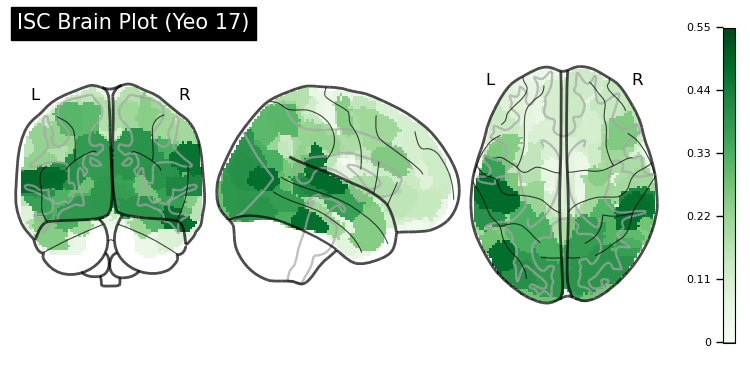

In [57]:
# Create figure showing average ISC across all participants - Yeo 17
display = plot_glass_brain(
    isc_brain_yeo_17.to_nifti(),
    colorbar=True,  # Show colorbar
    title='ISC Brain Plot (Yeo 17)',  # Title for the plot
    threshold='auto',  # Automatically calculate threshold for visualization
    plot_abs=True,  # Plot absolute values
    cmap='Greens',  # Choose a colormap (optional)
    figure=None,  # Default figure (None)
    annotate=True,  # Annotate positions
    black_bg=False,  # Black background (optional)
    radiological=False,  # Use radiological view
    vmin = 0,
    vmax = 0.55
)

display._cbar.set_ticks(np.linspace(0, 0.55, 6))
display._cbar.ax.tick_params(
    direction='out',
    length=5,
    width=1,
    labelsize=8
)

# Save the figure (Change here to Revision Folder!)
file_path_figure = r"C:\Users\Benutze\Documents\Promotion\Papers\Paper 4\Results\Figures_Revision\IS-RSA All Scenes\Average_ISC_All_Scenes_Yeo_17_greens.png"
display.savefig(file_path_figure, dpi=300)

#### Yay, both are identical --> plotting issue solved!! For the rest of the scrip: Use Yeo 17 to plot (because that is the order my data naturally is in!)

### 6. Calculate trait similarity

*Extract the vector of scores for the behavior we are interested in*

In [60]:
Neuroticism = HCP_behavioral_movie_main_89['NEOFAC_N']
Neuroticism_rank = rankdata(Neuroticism) #explicitely convert the raw scores to ranks

In [62]:
print(Neuroticism)

0      7.0
1     18.0
2     10.0
3      9.0
4     11.0
      ... 
84    16.0
85     9.0
86    15.0
87    12.0
88    17.0
Name: NEOFAC_N, Length: 89, dtype: float64


In [64]:
print(Neuroticism_rank)

[ 5.5 54.  14.5 10.5 18.  50.  64.  50.  69.  23.  77.  29.  69.  73.5
 23.   1.5 34.5 54.  89.  45.   7.5 79.5 82.5 54.  18.  29.  88.  58.5
 86.5 23.  64.  85.  40.  58.5 69.  64.  86.5  7.5 64.  58.5 82.5 64.
 29.  45.  40.  50.  45.  23.  77.  58.5 40.  18.  14.5 10.5 34.5 50.
 82.5 34.5  4.   1.5 82.5 77.  45.  40.   5.5 10.5 73.5 73.5 69.  58.5
 79.5 14.5  3.  34.5 14.5 34.5 29.  29.  34.5 23.  58.5 69.  73.5 23.
 45.  10.5 40.  23.  50. ]


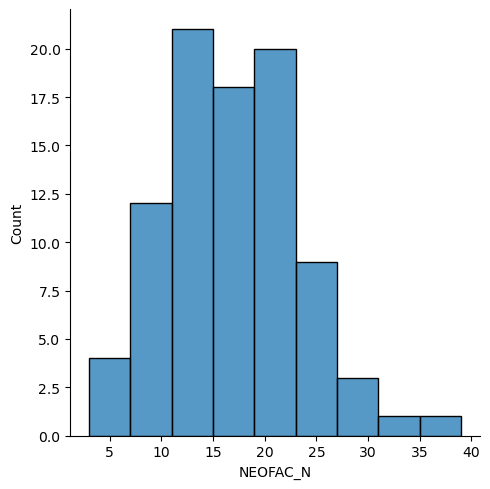

In [66]:
sns.displot(Neuroticism)

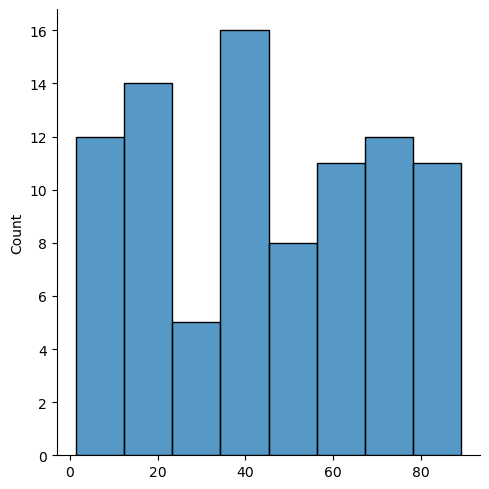

In [68]:
sns.displot(Neuroticism_rank)

We're going to explore three types of similarity structures (Nearest neighbour, Anna Karenina, Gaussian Model) to see which one is a better fit for our data. Since ISC matrices are inherently a measure of similarity and Euclidean Distance is a distance measure, Euclidean distances are converted to similarities using 'Adjacency.distance_to_similarity'. Therefore we can interpret positive RSA values as reflecting higher representational similarity. After sorting subjects in order of neuroticism rank score from high to low, the expected diagonal structure (each subject is more similar to his/her neighbours) becomes more visible. Only for visualization purposes!! Needs to be the original order to perform the IS-RSA. 

**NN-Model** 

*define helper functions*

In [70]:
# Define some helper functions
def sort_square_mtx(mtx, vct):
    """
    Sorts rows/columns of a matrix according to a separate vector.
    """
    
    inds = vct.argsort()
    mtx_sorted = mtx.copy()
    mtx_sorted = mtx_sorted[inds, :]
    mtx_sorted = mtx_sorted[:, inds]
    
    return mtx_sorted

def scale_mtx(mtx):
    """
    Scales a matrix to have values between 0 and 1.
    """
    return (mtx-np.min(mtx))/(np.max(mtx)-np.min(mtx))

Text(0.5, 1.0, 'NN Behavioral Similarity Matrix (After Sorting)')

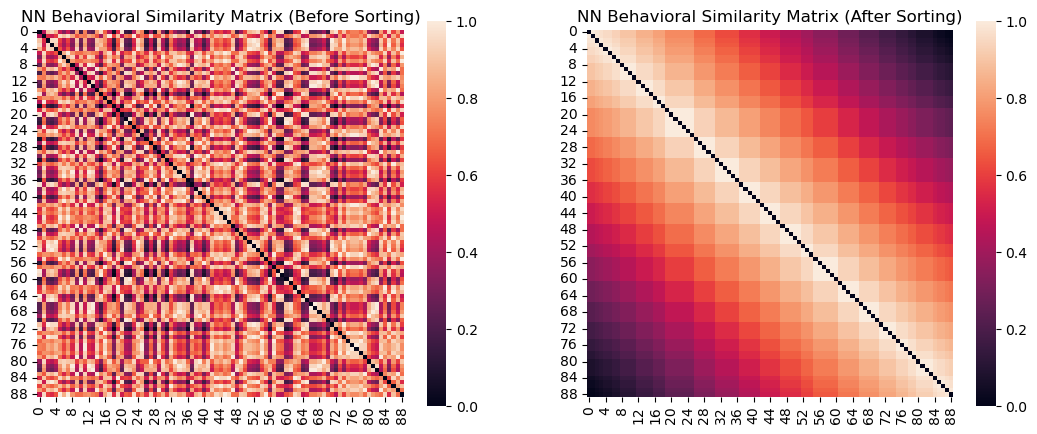

In [72]:
behav_sim_nn = Adjacency(scale_mtx(pairwise_distances(np.reshape(Neuroticism_rank, (-1, 1)), metric='euclidean')), matrix_type='distance')
behav_sim_nn = behav_sim_nn.distance_to_similarity()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13,5))
behav_sim_nn.plot(axes=ax1)
ax1.set_title("NN Behavioral Similarity Matrix (Before Sorting)", fontsize=12)

sns.heatmap(sort_square_mtx(behav_sim_nn.squareform(), Neuroticism), ax = ax2, square=True)
ax2.set_title("NN Behavioral Similarity Matrix (After Sorting)", fontsize=12)

# Save the figure
#file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\Behavioral_similarity_NN.png"
#fig.savefig(file_path_figure, dpi=300, bbox_inches='tight')

**Anna-Karenina Model**

Text(0.5, 1.0, 'AnnaK Behavioral Similarity Matrix (After Sorting)')

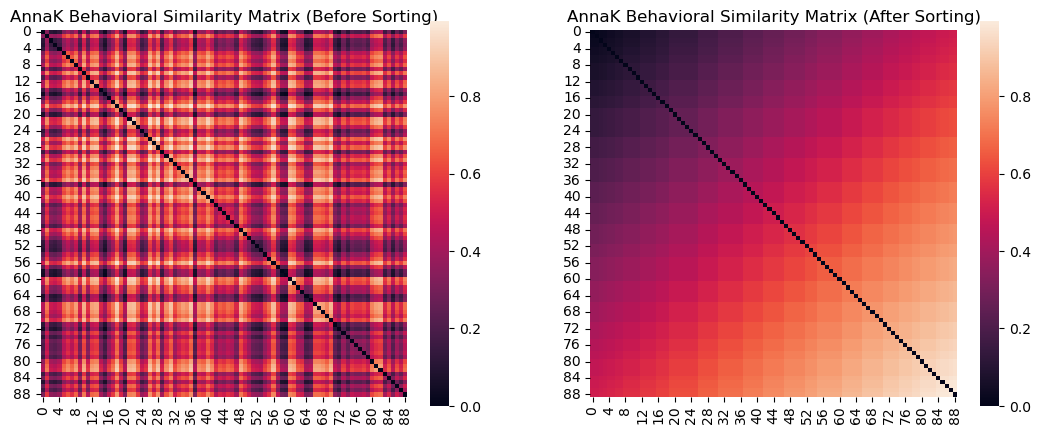

In [75]:
behav_sim_annak = np.zeros((n_subs, n_subs))

for i in range(n_subs):
    for j in range(n_subs):
        if i < j:
            sim_ij = np.mean([Neuroticism_rank[i], Neuroticism_rank[j]])/n_subs
            behav_sim_annak[i,j] = sim_ij
            behav_sim_annak[j,i] = sim_ij
        elif i==j:
            behav_sim_annak[i,j] = 1

behav_sim_annak = Adjacency(behav_sim_annak, matrix_type='similarity')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13,5))
behav_sim_annak.plot(axes=ax1)
ax1.set_title("AnnaK Behavioral Similarity Matrix (Before Sorting)", fontsize=12)

sns.heatmap(sort_square_mtx(behav_sim_annak.squareform(), Neuroticism), ax = ax2, square=True)
ax2.set_title("AnnaK Behavioral Similarity Matrix (After Sorting)", fontsize=12)

# Save the figure
# file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\Behavioral_similarity_AnnaK.png"
# fig.savefig(file_path_figure, dpi=300, bbox_inches='tight')

**Test with Reversed AnnaK Model --> Reverse distance metric** 

Text(0.5, 1.0, 'Reversed AnnaK Behavioral Similarity Matrix (After Sorting)')

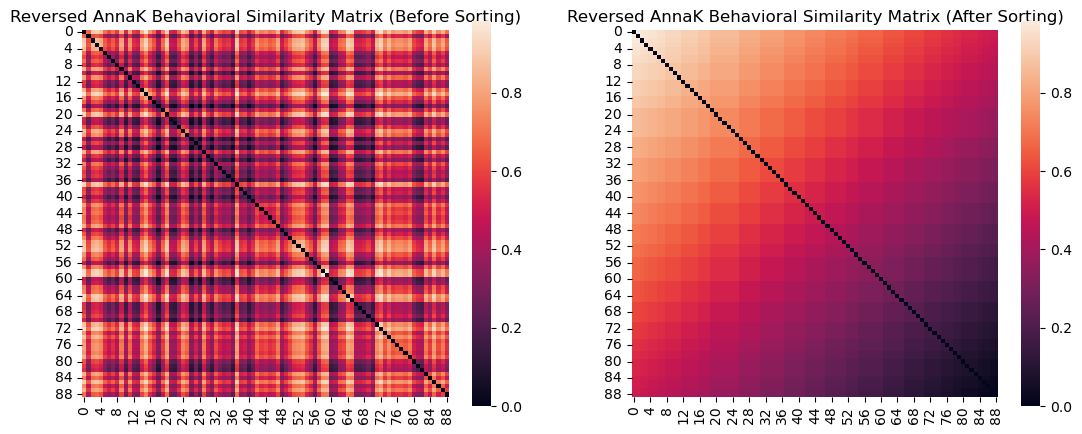

In [77]:
behav_sim_annak_reversed = np.zeros((n_subs, n_subs))

for i in range(n_subs):
    for j in range(n_subs):
        if i < j:
            sim_ij = 1 - (np.mean([Neuroticism_rank[i], Neuroticism_rank[j]]) / n_subs)
            behav_sim_annak_reversed[i,j] = sim_ij
            behav_sim_annak_reversed[j,i] = sim_ij
        elif i == j:
            behav_sim_annak_reversed[i,j] = 1

behav_sim_annak_reversed = Adjacency(behav_sim_annak_reversed, matrix_type='similarity')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13,5))
behav_sim_annak_reversed.plot(axes=ax1)
ax1.set_title("Reversed AnnaK Behavioral Similarity Matrix (Before Sorting)", fontsize=12)

sns.heatmap(sort_square_mtx(behav_sim_annak_reversed.squareform(), Neuroticism), ax=ax2, square=True)
ax2.set_title("Reversed AnnaK Behavioral Similarity Matrix (After Sorting)", fontsize=12)

# Save the figure
#file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\Behavioral_similarity_Reversed_AnnaK.png"
#fig.savefig(file_path_figure, dpi=300, bbox_inches='tight')


In [79]:
print(len(Neuroticism))  # Should print 89 if there are 89 subjects
print(behav_sim_annak.shape)  # Should print (89, 89) if your matrix has 89x89 dimensions

89
<bound method Adjacency.shape of nltools.data.adjacency.Adjacency(shape=(3916,), square_shape=(89, 89), Y=(0, 0), is_symmetric=True,matrix_type=similarity)>


**Gaussian Model**

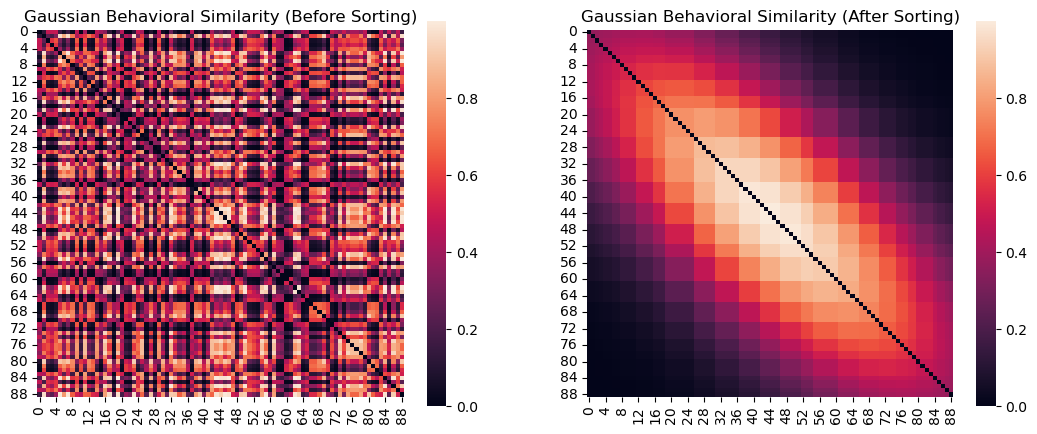

In [81]:
# Parameters
sigma = 0.3  # Spread of the Gaussian function
lambda_mid = 2  # Strength of the middle weighting

# Normalize neuroticism scores to range [0,1]
Neuroticism_norm = (Neuroticism_rank - np.min(Neuroticism_rank)) / (np.max(Neuroticism_rank) - np.min(Neuroticism_rank))

# Compute Gaussian similarity matrix
n_subs = len(Neuroticism_norm)
behav_sim_gauss = np.zeros((n_subs, n_subs))

# Middle-weighting function: individuals in the middle of the distribution get a boost
middle_weight = np.exp(-((Neuroticism_norm - 0.5) ** 2) * lambda_mid)

for i in range(n_subs):
    for j in range(n_subs):
        gaussian_sim = np.exp(-((Neuroticism_norm[i] - Neuroticism_norm[j]) ** 2) / (2 * sigma ** 2))
        
        # Apply the middle-weighting function
        behav_sim_gauss[i, j] = gaussian_sim * middle_weight[i] * middle_weight[j]

# Convert to Adjacency object
behav_sim_gauss = Adjacency(behav_sim_gauss, matrix_type='similarity')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
behav_sim_gauss.plot(axes=ax1)
ax1.set_title("Gaussian Behavioral Similarity (Before Sorting)", fontsize=12)

sns.heatmap(sort_square_mtx(behav_sim_gauss.squareform(), Neuroticism_rank), ax=ax2, square=True)
ax2.set_title("Gaussian Behavioral Similarity (After Sorting)", fontsize=12)

# Save the figure
#file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\Behavioral_similarity_Gauss.png"
#fig.savefig(file_path_figure, dpi=300, bbox_inches='tight')

plt.show()

### 7. Compute Inter-subject Representational Similarity Analyis (IS-RSA)

In [83]:
isrsa_nn, isrsa_annak, isrsa_annak_reversed, isrsa_gauss = {}, {}, {}, {}
for node in range(len(similarity_matrices)):
    isrsa_nn[node] = similarity_matrices[node].similarity(behav_sim_nn, metric='spearman', n_permute=1, n_jobs=1 )['correlation']
    isrsa_annak[node] = similarity_matrices[node].similarity(behav_sim_annak, metric='spearman', n_permute=1, n_jobs=1 )['correlation']
    isrsa_annak_reversed[node] = similarity_matrices[node].similarity(behav_sim_annak_reversed, metric='spearman', n_permute=1, n_jobs=1 )['correlation']
    isrsa_gauss[node] = similarity_matrices[node].similarity(behav_sim_gauss, metric='spearman', n_permute=1, n_jobs=1 )['correlation']

*Comparing different models (without AnnaK Reversed)*

Nearest Neighbor Model: t = -0.44, p = 0.660
Anna Karenina Model: t = -21.19, p = 0.000
Gaussian Model: t = 0.28, p = 0.781


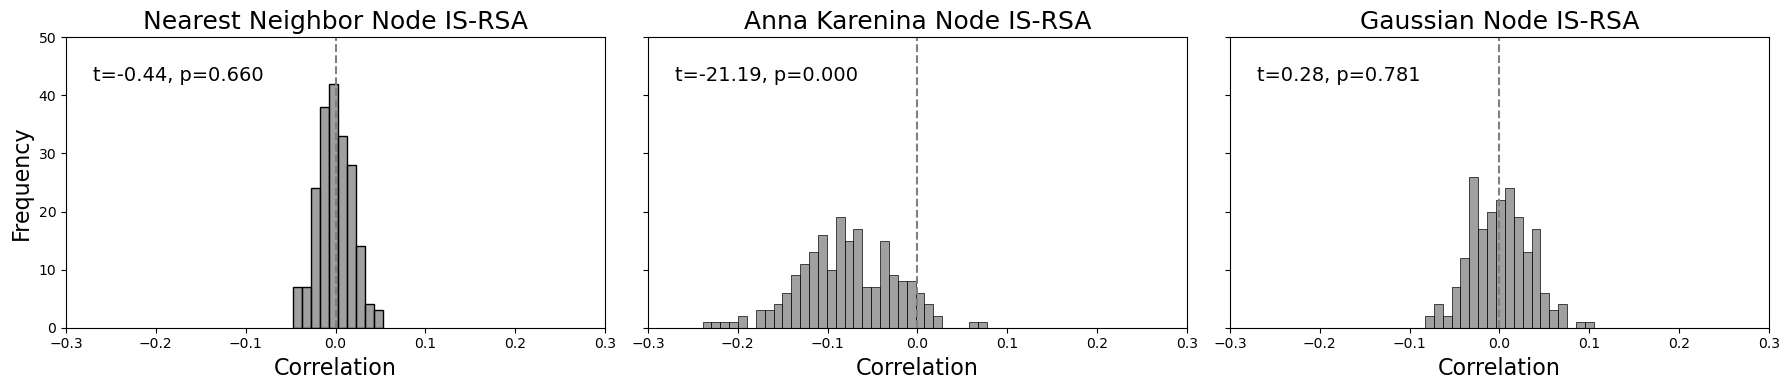

In [85]:
bin_width = 0.01  # Set the same bin width for all plots

f, a = plt.subplots(ncols=3, figsize=(18, 4), sharex=True, sharey=True)

# Nearest Neighbor Model
values_nn = list(isrsa_nn.values())
# values_nn_z = np.arctanh(values_nn)
t_nn, p_nn = ttest_1samp(values_nn, 0)
print(f"Nearest Neighbor Model: t = {t_nn:.2f}, p = {p_nn:.3f}")

sns.histplot(values_nn, ax=a[0], binwidth=bin_width, color = 'gray')
a[0].axvline(0, color='gray', linestyle='--')
a[0].set_xlim(-0.3, 0.3)
a[0].set_ylim(0, 50)
a[0].set_ylabel('Frequency', fontsize=16)
a[0].set_xlabel('Correlation', fontsize=16)
a[0].set_title('Nearest Neighbor Node IS-RSA', fontsize=18)
a[0].annotate(f't={t_nn:.2f}, p={p_nn:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Anna Karenina Model
values_annak = list(isrsa_annak.values())
t_annak, p_annak = ttest_1samp(values_annak, 0)
print(f"Anna Karenina Model: t = {t_annak:.2f}, p = {p_annak:.3f}")

sns.histplot(values_annak, ax=a[1], binwidth=bin_width, color = 'gray')
a[1].axvline(0, color='gray', linestyle='--')
a[0].set_xlim(-0.3, 0.3)
a[0].set_ylim(0, 50)
a[1].set_ylabel('Frequency', fontsize=16)
a[1].set_xlabel('Correlation', fontsize=16)
a[1].set_title('Anna Karenina Node IS-RSA', fontsize=18)
a[1].annotate(f't={t_annak:.2f}, p={p_annak:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Gaussian Model
values_gauss = list(isrsa_gauss.values())
t_gauss, p_gauss = ttest_1samp(values_gauss, 0)
print(f"Gaussian Model: t = {t_gauss:.2f}, p = {p_gauss:.3f}")

sns.histplot(values_gauss, ax=a[2], binwidth=bin_width, color = 'gray')
a[2].axvline(0, color='gray', linestyle='--')
a[0].set_xlim(-0.3, 0.3)
a[0].set_ylim(0, 50)
a[2].set_ylabel('Frequency', fontsize=16)
a[2].set_xlabel('Correlation', fontsize=16)
a[2].set_title('Gaussian Node IS-RSA', fontsize=18)
a[2].annotate(f't={t_gauss:.2f}, p={p_gauss:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

plt.tight_layout()


# Save the figure
#file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\IS_RSA_All_regions_All_Scenes.png"
#plt.savefig(file_path_figure, dpi=300, bbox_inches='tight')

plt.show()

*TEST!! Comparing different models (with AnnaK Reversed)*

Nearest Neighbor Model: t = -0.44, p = 0.660
Anna Karenina Model: t = -21.19, p = 0.000
Anna Karenina Model Reversed: t = 21.19, p = 0.000
Gaussian Model: t = 0.28, p = 0.781


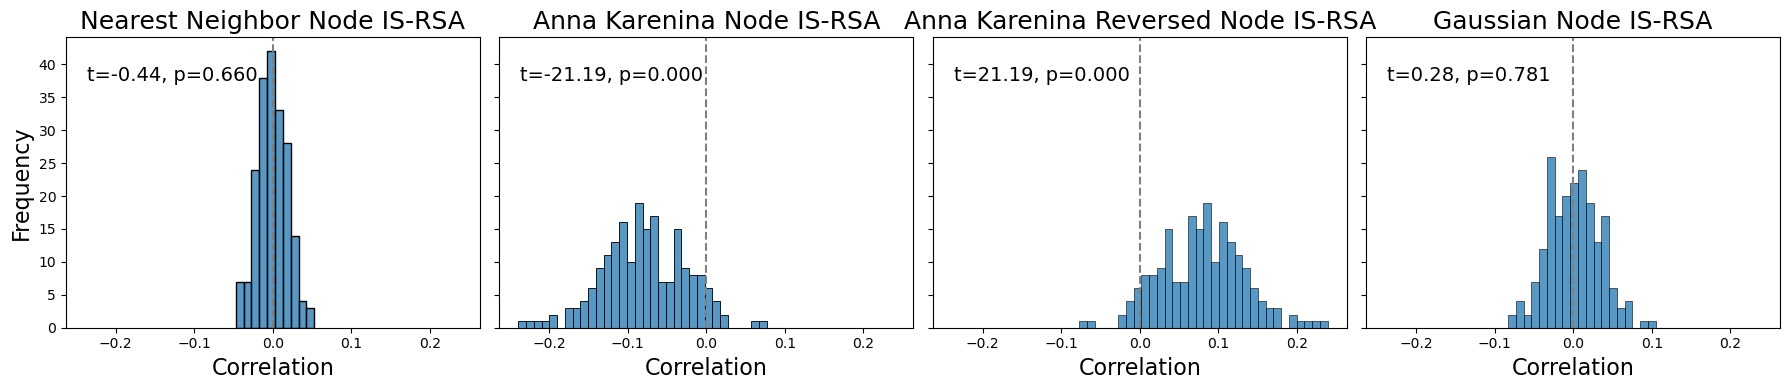

In [214]:
bin_width = 0.01  # Set the same bin width for all plots

f, a = plt.subplots(ncols=4, figsize=(18, 4), sharex=True, sharey=True)

# Nearest Neighbor Model
values_nn = list(isrsa_nn.values())
t_nn, p_nn = ttest_1samp(values_nn, 0)
print(f"Nearest Neighbor Model: t = {t_nn:.2f}, p = {p_nn:.3f}")

sns.histplot(values_nn, ax=a[0], binwidth=bin_width)
a[0].axvline(0, color='gray', linestyle='--')
a[0].set_ylabel('Frequency', fontsize=16)
a[0].set_xlabel('Correlation', fontsize=16)
a[0].set_title('Nearest Neighbor Node IS-RSA', fontsize=18)
a[0].annotate(f't={t_nn:.2f}, p={p_nn:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Anna Karenina Model
values_annak = list(isrsa_annak.values())
t_annak, p_annak = ttest_1samp(values_annak, 0)
print(f"Anna Karenina Model: t = {t_annak:.2f}, p = {p_annak:.3f}")

sns.histplot(values_annak, ax=a[1], binwidth=bin_width)
a[1].axvline(0, color='gray', linestyle='--')
a[1].set_ylabel('Frequency', fontsize=16)
a[1].set_xlabel('Correlation', fontsize=16)
a[1].set_title('Anna Karenina Node IS-RSA', fontsize=18)
a[1].annotate(f't={t_annak:.2f}, p={p_annak:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Anna Karenina Model Reversed
values_annak_reversed = list(isrsa_annak_reversed.values())
t_annak_reversed, p_annak_reversed = ttest_1samp(values_annak_reversed, 0)
print(f"Anna Karenina Model Reversed: t = {t_annak_reversed:.2f}, p = {p_annak_reversed:.3f}")

sns.histplot(values_annak_reversed, ax=a[2], binwidth=bin_width)
a[2].axvline(0, color='gray', linestyle='--')
a[2].set_ylabel('Frequency', fontsize=16)
a[2].set_xlabel('Correlation', fontsize=16)
a[2].set_title('Anna Karenina Reversed Node IS-RSA', fontsize=18)
a[2].annotate(f't={t_annak_reversed:.2f}, p={p_annak_reversed:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Gaussian Model
values_gauss = list(isrsa_gauss.values())
t_gauss, p_gauss = ttest_1samp(values_gauss, 0)
print(f"Gaussian Model: t = {t_gauss:.2f}, p = {p_gauss:.3f}")

sns.histplot(values_gauss, ax=a[3], binwidth=bin_width)
a[3].axvline(0, color='gray', linestyle='--')
a[3].set_ylabel('Frequency', fontsize=16)
a[3].set_xlabel('Correlation', fontsize=16)
a[3].set_title('Gaussian Node IS-RSA', fontsize=18)
a[3].annotate(f't={t_gauss:.2f}, p={p_gauss:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

plt.tight_layout()


# Save the figure
file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\IS_RSA_All_regions_All_Scenes_plus_AnnaK_rev.png"
plt.savefig(file_path_figure, dpi=300, bbox_inches='tight')

plt.show()

### 8. Network-Specific Analyses!!

From Josh Email: Question: What is the right node order? Becuase there are two files with different node orders, depending on whether it is in reference to the YEO7 or the YEO17 Parcellation: 

*Now the Yan parcellation is a different (newer parcellation) than the Yeo networks, which came out in 2011... but every time a new parcellation is created, people usually label the nodes in reference to the original 7 or 17 Yeo networks, as a frame of reference.  So the Yan paper did this -- and downloading the Yan parcellations, indeed, the parcellation stays the same, but the names of the nodes changes, based on whether they are being names relative to the 7 or 17 original Yeo parcellation.   So ya, there's no difference in the borders of the Yan parcellation between the yeo7 or yeo17 version... just they have names mapped to a different reference parcellations for naming purposes.*

Second Mail from Josh: 

yaa yaa yaa your intuition is correct.  the centroid coordinates should be the same -- thus, it does indeed look like the ordering of the nodes has changed between the yeo7 and yeo17 versions of the Yan parcellation, even if the actual borders did not change.  Thus, I think the fix is quick!  You just need to iterate through the voxel coordinates of the yeo7 csv and find its match in the yeo17 list, so you can make the mapping to correctly plot both of them.  when you do this, those plots you attached should be identical. 

to extract these data, I used the yeo17 version of the Yan parcellation -- so thats the ordering it will naturally be in.

In [216]:
# Define Nodes belonging to YEO 17 (specific networks)

nodes_yeo_17_network_1_TempPar = [0,1,2,100,101,102,116]
nodes_yeo_17_network_2_DefaultC = [3,4,5,103,104,105]
nodes_yeo_17_network_3_DefaultB = [6,7,8,9,10,11,12,13,14,15,16,17,108,109,111,114,115]
nodes_yeo_17_network_4_DefaultA = [18,19,20,21,22,23,24,25,26,27,107,117,119,120,121,122,123,124,125,126,127]
nodes_yeo_17_network_5_ContC = [28,29,30,128,129,130]
nodes_yeo_17_network_6_ContB = [31,32,33,34,110,118,131,132,133,134]
nodes_yeo_17_network_7_ContA = [35,36,37,38,39,40,41,135,136,137,138,140,141,169]
nodes_yeo_17_network_8_LimbicA = [42,43,142,143]
nodes_yeo_17_network_9_LimbicB = [44,45,46,144,145,146]
nodes_yeo_17_network_10_SalVent_AttnB = [47,48,49,50,106,112,113,139,147,148,149,150]
nodes_yeo_17_network_11_SalVent_AttnA = [51,52,53,54,55,56,151,152,153,154,155,156,178]
nodes_yeo_17_network_12_DorsAttnB = [57,58,59,60,61,62,157,158,159,160,161,162]
nodes_yeo_17_network_13_DorsAttnA = [63,64,65,66,67,68,69,163,164,165,166,167,168]
nodes_yeo_17_network_14_SomMotB = [70,71,72,73,74,75,76,77,78,170,171,172,173,174,175,176,177]
nodes_yeo_17_network_15_SomMotA = [79,80,81,82,83,84,85,86,87,88,179,180,181,182,183,184,185,186,187,188]
nodes_yeo_17_network_16_VisPeri = [89,90,91,92,189,190,191,192]
nodes_yeo_17_network_17_VisCent = [93,94,95,96,97,98,99,193,194,195,196,197,198,199]

In [224]:
# Define nodes belonging to YEO 7 (specific networks) --> According to yeo_17_to_7_matches_with_coords.csv

nodes_yeo_7_network_1_Default = [0,2,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,30,33,50,103,105,107,108,109,111,114,115,116,117,118,119,120,121,122,123,124,125,126,127]
nodes_yeo_7_network_2_Cont = [29,31,32,34,35,36,38,39,47,49,106,110,113,128,130,131,132,133,134,136,138,139,147,149,150]
nodes_yeo_7_network_3_Limbic = [42,43,44,45,46,142,143,144,145,146]
nodes_yeo_7_network_4_SalVentAttn = [1,41,48,51,52,53,54,55,56,78,100,101,112,141,148,151,152,153,154,155,156,178]
nodes_yeo_7_network_5_DorsAttn = [37,40,57,58,59,60,61,62,63,64,65,67,68,69,129,135,137,140,157,158,159,160,161,162,163,164,165,166,167,168,169]
nodes_yeo_7_network_6_SomMot = [70,71,72,73,74,75,76,77,79,80,81,82,83,84,85,86,87,88,102,170,171,172,173,174,175,176,177,179,180,181,182,183,184,185,186,187,188]
nodes_yeo_7_network_7_Vis = [4,66,89,90,91,92,93,94,95,96,97,98,99,104,189,190,191,192,193,194,195,196,197,198,199]


In [226]:
network_dict_yeo_17 = {
    "network_1_yeo_17_TempPar": nodes_yeo_17_network_1_TempPar,
    "network_2_yeo_17_DefaultC": nodes_yeo_17_network_2_DefaultC,
    "network_3_yeo_17_DefaultB": nodes_yeo_17_network_3_DefaultB,
    "network_4_yeo_17_DefaultA": nodes_yeo_17_network_4_DefaultA,
    "network_5_yeo_17_ContC": nodes_yeo_17_network_5_ContC,
    "network_6_yeo_17_ContB": nodes_yeo_17_network_6_ContB,
    "network_7_yeo_17_ContA": nodes_yeo_17_network_7_ContA,
    "network_8_yeo_17_LimbicA": nodes_yeo_17_network_8_LimbicA,
    "network_9_yeo_17_LimbicB": nodes_yeo_17_network_9_LimbicB,
    "network_10_yeo_17_SalVentAttnB": nodes_yeo_17_network_10_SalVent_AttnB,
    "network_11_yeo_17_SalVentAttnA": nodes_yeo_17_network_11_SalVent_AttnA,
    "network_12_yeo_17_DorsAttnB": nodes_yeo_17_network_12_DorsAttnB,
    "network_13_yeo_17_DorsAttnA": nodes_yeo_17_network_13_DorsAttnA,
    "network_14_yeo_17_SomMotB": nodes_yeo_17_network_14_SomMotB,
    "network_15_yeo_17_SomMotA": nodes_yeo_17_network_15_SomMotA,
    "network_16_yeo_17_VisPeri": nodes_yeo_17_network_16_VisPeri,
    "network_17_yeo_17_VisCent": nodes_yeo_17_network_17_VisCent,
}

In [228]:
network_dict_yeo_7 = {
    "network_1_yeo_7_Default": nodes_yeo_7_network_1_Default,
    "network_2_yeo_7_Cont": nodes_yeo_7_network_2_Cont,
    "network_3_yeo_7_Limbic": nodes_yeo_7_network_3_Limbic,
    "network_4_yeo_7_SalVentAttn": nodes_yeo_7_network_4_SalVentAttn,
    "network_5_yeo_7_DorsAttn": nodes_yeo_7_network_5_DorsAttn,
    "network_6_yeo_7_SomMot": nodes_yeo_7_network_6_SomMot,
    "network_7_yeo_7_Vis": nodes_yeo_7_network_7_Vis,
}

Nearest Neighbor Model: t = -0.47, p = 0.641
Anna Karenina Model: t = -25.09, p = 0.000
Gaussian Model: t = -0.08, p = 0.935


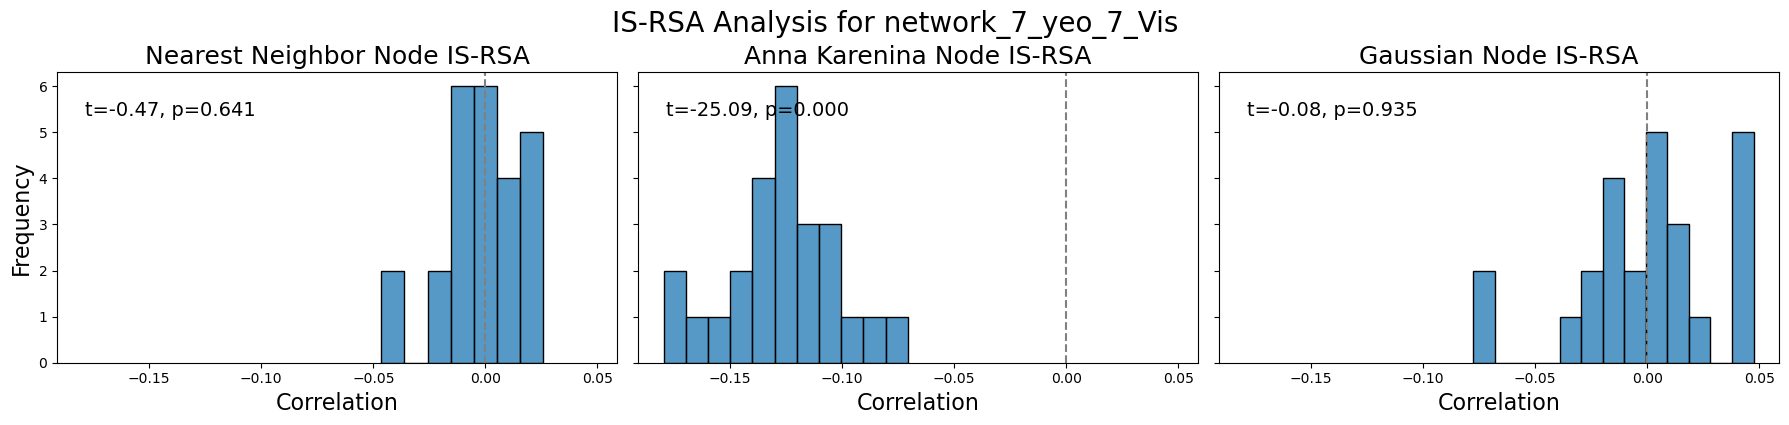

In [244]:
# Extract values for the selected nodes

network_name = "network_7_yeo_7_Vis" #Change Network Name (from dictionary) here!

nodes_belonging_to_network = network_dict_yeo_7[network_name]

values_network_nn = [isrsa_nn[node] for node in nodes_belonging_to_network if node in isrsa_nn]
values_network_annak = [isrsa_annak[node] for node in nodes_belonging_to_network if node in isrsa_annak]
values_network_gauss = [isrsa_gauss[node] for node in nodes_belonging_to_network if node in isrsa_gauss]


bin_width = 0.01  # Set the same bin width for all plots

f, a = plt.subplots(ncols=3, figsize=(18, 4), sharex=True, sharey=True)

# Nearest Neighbor Model
t_nn, p_nn = ttest_1samp(values_network_nn, 0)
print(f"Nearest Neighbor Model: t = {t_nn:.2f}, p = {p_nn:.3f}")

sns.histplot(values_network_nn, ax=a[0], binwidth=bin_width)
a[0].axvline(0, color='gray', linestyle='--')
a[0].set_ylabel('Frequency', fontsize=16)
a[0].set_xlabel('Correlation', fontsize=16)
a[0].set_title('Nearest Neighbor Node IS-RSA', fontsize=18)
a[0].annotate(f't={t_nn:.2f}, p={p_nn:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Anna Karenina Model
t_annak, p_annak = ttest_1samp(values_network_annak, 0)
print(f"Anna Karenina Model: t = {t_annak:.2f}, p = {p_annak:.3f}")

sns.histplot(values_network_annak, ax=a[1], binwidth=bin_width)
a[1].axvline(0, color='gray', linestyle='--')
a[1].set_ylabel('Frequency', fontsize=16)
a[1].set_xlabel('Correlation', fontsize=16)
a[1].set_title('Anna Karenina Node IS-RSA', fontsize=18)
a[1].annotate(f't={t_annak:.2f}, p={p_annak:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Gaussian Model
t_gauss, p_gauss = ttest_1samp(values_network_gauss, 0)
print(f"Gaussian Model: t = {t_gauss:.2f}, p = {p_gauss:.3f}")

sns.histplot(values_network_gauss, ax=a[2], binwidth=bin_width)
a[2].axvline(0, color='gray', linestyle='--')
a[2].set_ylabel('Frequency', fontsize=16)
a[2].set_xlabel('Correlation', fontsize=16)
a[2].set_title('Gaussian Node IS-RSA', fontsize=18)
a[2].annotate(f't={t_gauss:.2f}, p={p_gauss:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

plt.tight_layout()

plt.suptitle(f"IS-RSA Analysis for {network_name}", fontsize=20, y=1.05)

# Save the figure
file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\Network_specific_analyses\Yeo_7"
plt.savefig(f"{file_path_figure}/IS_RSA_{network_name}_All_Scenes.png", dpi=300, bbox_inches='tight')

plt.show()

### 9. Compute significance at the brain region-specific level 

In [246]:
isrsa_nn_r, isrsa_nn_p = {}, {}
isrsa_annak_r, isrsa_annak_p = {}, {}
isrsa_annak_reversed_r, isrsa_annak_reversed_p = {}, {}
isrsa_gauss_r, isrsa_gauss_p = {}, {}
for node in range(len(similarity_matrices)):
    if node==0:
        print("Doing node {} of {}...".format(node+1, len(similarity_matrices)), end =" ")
    else:
        print("{}..".format(node+1), end = " ")
    stats_nn = similarity_matrices[node].similarity(behav_sim_nn, metric='spearman', n_permute=5000, n_jobs=1 )
    isrsa_nn_r[node] = stats_nn['correlation']
    isrsa_nn_p[node] = stats_nn['p']
    
    stats_annak = similarity_matrices[node].similarity(behav_sim_annak, metric='spearman', n_permute=5000, n_jobs=1 )
    isrsa_annak_r[node] = stats_annak['correlation']
    isrsa_annak_p[node] = stats_annak['p']

    stats_annak_reversed = similarity_matrices[node].similarity(behav_sim_annak_reversed, metric='spearman', n_permute=5000, n_jobs=1 )
    isrsa_annak_reversed_r[node] = stats_annak_reversed['correlation']
    isrsa_annak_reversed_p[node] = stats_annak_reversed['p']
    
    stats_gauss = similarity_matrices[node].similarity(behav_sim_gauss, metric='spearman', n_permute=5000, n_jobs=1 )
    isrsa_gauss_r[node] = stats_gauss['correlation']
    isrsa_gauss_p[node] = stats_gauss['p']

Doing node 1 of 200... 2.. 3.. 4.. 5.. 6.. 7.. 8.. 9.. 10.. 11.. 12.. 13.. 14.. 15.. 16.. 17.. 18.. 19.. 20.. 21.. 22.. 23.. 24.. 25.. 26.. 27.. 28.. 29.. 30.. 31.. 32.. 33.. 34.. 35.. 36.. 37.. 38.. 39.. 40.. 41.. 42.. 43.. 44.. 45.. 46.. 47.. 48.. 49.. 50.. 51.. 52.. 53.. 54.. 55.. 56.. 57.. 58.. 59.. 60.. 61.. 62.. 63.. 64.. 65.. 66.. 67.. 68.. 69.. 70.. 71.. 72.. 73.. 74.. 75.. 76.. 77.. 78.. 79.. 80.. 81.. 82.. 83.. 84.. 85.. 86.. 87.. 88.. 89.. 90.. 91.. 92.. 93.. 94.. 95.. 96.. 97.. 98.. 99.. 100.. 101.. 102.. 103.. 104.. 105.. 106.. 107.. 108.. 109.. 110.. 111.. 112.. 113.. 114.. 115.. 116.. 117.. 118.. 119.. 120.. 121.. 122.. 123.. 124.. 125.. 126.. 127.. 128.. 129.. 130.. 131.. 132.. 133.. 134.. 135.. 136.. 137.. 138.. 139.. 140.. 141.. 142.. 143.. 144.. 145.. 146.. 147.. 148.. 149.. 150.. 151.. 152.. 153.. 154.. 155.. 156.. 157.. 158.. 159.. 160.. 161.. 162.. 163.. 164.. 165.. 166.. 167.. 168.. 169.. 170.. 171.. 172.. 173.. 174.. 175.. 176.. 177.. 178.. 179.. 180.. 181.. 182

*Save r and p-vals to conduct ANOVAs and t-tests in different environment*

In [248]:
import pandas as pd
import os

folder_path = r"C:\Users\jop86ib\Documents\Paper 4\Results\IS_RSA_values"

# Create Dataframe NN

df_stats_nn = pd.DataFrame({
    'node': list(isrsa_nn_r.keys()),
    'r_value_nn_all_scenes': list(isrsa_nn_r.values()),
    'p_value_nn_all_scenes': list(isrsa_nn_p.values())
})


# Save the DataFrame NN
csv_file_path = os.path.join(folder_path, 'IS_RSA_values_all_scenes_nn.csv')
df_stats_nn.to_csv(csv_file_path, index=False)

# Create Dataframe AnnaK

df_stats_annak = pd.DataFrame({
    'node': list(isrsa_annak_r.keys()),
    'r_value_annak_all_scenes': list(isrsa_annak_r.values()),
    'p_value_annak_all_scenes': list(isrsa_annak_p.values())
})

# Save the DataFrame AnnaK
csv_file_path = os.path.join(folder_path, 'IS_RSA_values_all_scenes_annak.csv')
df_stats_annak.to_csv(csv_file_path, index=False)

# Create Dataframe Gauss

df_stats_gauss = pd.DataFrame({
    'node': list(isrsa_gauss_r.keys()),
    'r_value_gauss_all_scenes': list(isrsa_gauss_r.values()),
    'p_value_gauss_all_scenes': list(isrsa_gauss_p.values())
})


# Save the DataFrame Gauss
csv_file_path = os.path.join(folder_path, 'IS_RSA_values_all_scenes_gauss.csv')
df_stats_gauss.to_csv(csv_file_path, index=False)

*Create dictionary assigning node to node name*

*Node names are taken from here: https://github.com/ThomasYeoLab/CBIG/blob/master/stable_projects/brain_parcellation/Yan2023_homotopic/parcellations/MNI/yeo17/freeview_lut/200Parcels_Yeo2011_17Networks_LUT.txt*

In [250]:
node_names_yeo_17 = ['LH_TempPar_Temp_1',
              'LH_TempPar_Temp_2',
              'LH_TempPar_Temp_3',
              'LH_DefaultC_IPL',
              'LH_DefaultC_PHC',
              'LH_DefaultC_RSC',
              'LH_DefaultB_IPL_1',
              'LH_DefaultB_IPL_2',
              'LH_DefaultB_PFCd_1', 
              'LH_DefaultB_PFCd_2', 
              'LH_DefaultB_PFCl',
              'LH_DefaultB_PFCv_1', 
              'LH_DefaultB_PFCv_2', 
              'LH_DefaultB_PFCv_3',
              'LH_DefaultB_TempPole', 
              'LH_DefaultB_Temp_1', 
              'LH_DefaultB_Temp_2', 
              'LH_DefaultB_Temp_3', 
              'LH_DefaultA_IPL_1',
              'LH_DefaultA_PCC', 
              'LH_DefaultA_PFCd_1', 
              'LH_DefaultA_PFCd_2',
              'LH_DefaultA_PFCd_3', 
              'LH_DefaultA_PFCm_1', 
              'LH_DefaultA_PFCm_2',
              'LH_DefaultA_PFCm_3', 
              'LH_DefaultA_PFCm_4', 
              'LH_DefaultA_pCun',
              'LH_ContC_PCC', 
              'LH_ContC_pCun_1',
              'LH_ContC_pCun_2',
              'LH_ContB_FPole',
              'LH_ContB_IPL_1', 
              'LH_ContB_PFCv', 
              'LH_ContB_Temp',
              'LH_ContA_IPS_1',
              'LH_ContA_IPS_2', 
              'LH_ContA_PFCd',
              'LH_ContA_PFCl_1',
              'LH_ContA_PFCl_2', 
              'LH_ContA_PrCv_1',
              'LH_ContA_PrCv_2',
              'LH_LimbicA_Temp',
              'LH_LimbicA_TempPole',
              'LH_LimbicB_FPole',
              'LH_LimbicB_OFC_1',
              'LH_LimbicB_OFC_2',
              'LH_SalVentAttnB_FrMed_1',
              'LH_SalVentAttnB_FrMed_2',
              'LH_SalVentAttnB_PFCl_1', 
              'LH_SalVentAttnB_PFCl_2',
              'LH_SalVentAttnA_FrMed_1',
              'LH_SalVentAttnA_FrMed_2',
              'LH_SalVentAttnA_IPL', 
              'LH_SalVentAttnA_Ins_1',
              'LH_SalVentAttnA_Ins_2', 
              'LH_SalVentAttnA_SPL', 
              'LH_DorsAttnB_PostC_1',
              'LH_DorsAttnB_PostC_2',
              'LH_DorsAttnB_PrCd_1',
              'LH_DorsAttnB_PrCd_2',
              'LH_DorsAttnB_SPL_1',
              'LH_DorsAttnB_SPL_2', 
              'LH_DorsAttnA_IPS',
              'LH_DorsAttnA_SPL_1',
              'LH_DorsAttnA_SPL_2',
              'LH_DorsAttnA_TempOcc_1',
              'LH_DorsAttnA_TempOcc_2',
              'LH_DorsAttnA_TempOcc_3',
              'LH_DorsAttnA_TempOcc_4',
              'LH_SomMotB_1',
              'LH_SomMotB_2',
              'LH_SomMotB_3',
              'LH_SomMotB_4',
              'LH_SomMotB_Ins_1',
              'LH_SomMotB_Ins_2',
              'LH_SomMotB_Ins_3',
              'LH_SomMotB_ST_1',
              'LH_SomMotB_ST_2',
              'LH_SomMotA_1',
              'LH_SomMotA_10',
              'LH_SomMotA_2',
              'LH_SomMotA_3',
              'LH_SomMotA_4',
              'LH_SomMotA_5',
              'LH_SomMotA_6',
              'LH_SomMotA_7',
              'LH_SomMotA_8',
              'LH_SomMotA_9',
              'LH_VisPeri_ExStrInf_1',
              'LH_VisPeri_ExStrInf_2',
              'LH_VisPeri_ExStrSup',
              'LH_VisPeri_Striate',
              'LH_VisCent_ExStr_1',
              'LH_VisCent_ExStr_2',
              'LH_VisCent_ExStr_3',
              'LH_VisCent_ExStr_4',
              'LH_VisCent_ExStr_5',
              'LH_VisCent_ExStr_6',
              'LH_VisCent_Striate',
              'RH_TempPar_Temp_1',
              'RH_TempPar_Temp_2',
              'RH_TempPar_Temp_3',
              'RH_DefaultC_IPL',
              'RH_DefaultC_PHC',
              'RH_DefaultC_RSC',
              'RH_SalVentAttnB_IPL',
              'RH_DefaultA_IPL_1',
              'RH_DefaultB_PFCd_1',
              'RH_DefaultB_PFCd_2',
              'RH_ContB_PFCl',
              'RH_DefaultB_PFCv_1',
              'RH_SalVentAttnB_PFCv_1',
              'RH_SalVentAttnB_PFCv_2',
              'RH_DefaultB_TempPole',
              'RH_DefaultB_Temp_1',
              'RH_TempPar_Temp_4',
              'RH_DefaultA_Temp',
              'RH_ContB_IPL_2',
              'RH_DefaultA_PCC',
              'RH_DefaultA_PFCd_1',
              'RH_DefaultA_PFCd_2',
              'RH_DefaultA_PFCd_3',
              'RH_DefaultA_PFCm_1',
              'RH_DefaultA_PFCm_2',
              'RH_DefaultA_PFCm_3',
              'RH_DefaultA_PFCm_4',
              'RH_DefaultA_pCun',
              'RH_ContC_PCC',
              'RH_ContC_pCun_1',
              'RH_ContC_pCun_2',
              'RH_ContB_FPole',
              'RH_ContB_IPL_1',
              'RH_ContB_PFCv',
              'RH_ContB_Temp',
              'RH_ContA_IPS_1',
              'RH_ContA_IPS_2',
              'RH_ContA_PFCd',
              'RH_ContA_PFCl_1',
              'RH_SalVentAttnB_PFCl_3',
              'RH_ContA_PrCv_1',
              'RH_ContA_PrCv_2',
              'RH_LimbicA_Temp',
              'RH_LimbicA_TempPole',
              'RH_LimbicB_FPole',
              'RH_LimbicB_OFC_1',
              'RH_LimbicB_OFC_2',
              'RH_SalVentAttnB_FrMed_1',
              'RH_SalVentAttnB_FrMed_2',
              'RH_SalVentAttnB_PFCl_1',
              'RH_SalVentAttnB_PFCl_2',
              'RH_SalVentAttnA_FrMed_1',
              'RH_SalVentAttnA_FrMed_2',
              'RH_SalVentAttnA_IPL',
              'RH_SalVentAttnA_Ins_1',
              'RH_SalVentAttnA_Ins_2',
              'RH_SalVentAttnA_SPL',
              'RH_DorsAttnB_PostC_1',
              'RH_DorsAttnB_PostC_2',
              'RH_DorsAttnB_PrCd_1',
              'RH_DorsAttnB_PrCd_2',
              'RH_DorsAttnB_SPL_1',
              'RH_DorsAttnB_SPL_2',
              'RH_DorsAttnA_IPS',
              'RH_DorsAttnA_SPL_1',
              'RH_DorsAttnA_SPL_2',
              'RH_DorsAttnA_TempOcc_1',
              'RH_DorsAttnA_TempOcc_2',
              'RH_DorsAttnA_TempOcc_3',
              'RH_ContA_TempOcc',
              'RH_SomMotB_1',
              'RH_SomMotB_2',
              'RH_SomMotB_3',
              'RH_SomMotB_4',
              'RH_SomMotB_Ins_1',
              'RH_SomMotB_Ins_2',
              'RH_SomMotB_Ins_3',
              'RH_SomMotB_ST_1',
              'RH_SalVentAttnA_ST',
              'RH_SomMotA_1',
              'RH_SomMotA_10',
              'RH_SomMotA_2',
              'RH_SomMotA_3',
              'RH_SomMotA_4',
              'RH_SomMotA_5',
              'RH_SomMotA_6',
              'RH_SomMotA_7',
              'RH_SomMotA_8',
              'RH_SomMotA_9',
              'RH_VisPeri_ExStrInf_1',
              'RH_VisPeri_ExStrInf_2',
              'RH_VisPeri_ExStrSup',
              'RH_VisPeri_Striate',
              'RH_VisCent_ExStr_1',
              'RH_VisCent_ExStr_2',
              'RH_VisCent_ExStr_3',
              'RH_VisCent_ExStr_4',
              'RH_VisCent_ExStr_5',
              'RH_VisCent_ExStr_6',
              'RH_VisCent_Striate']

In [252]:
print(len(node_names_yeo_17))

200


In [254]:
node_name_yeo_17_dict = {i: name for i, name in enumerate(node_names_yeo_17)}
#print(node_name_dict)

##### *Significant Nodes for NN-Model*

In [288]:
significant_nodes_nn = [node for node in isrsa_nn_p if isrsa_nn_p[node] < 0.05]
significant_nodes_names_nn = [node_name_yeo_17_dict[node] for node in significant_nodes_nn] 
significant_r_values_nn = [isrsa_nn_r[node] for node in significant_nodes_nn]
significant_p_values_nn = [isrsa_nn_p[node] for node in significant_nodes_nn]


print("Significant Nodes NN Model:", significant_nodes_nn)
print("Significant Nodes Names NN Model:", significant_nodes_names_nn)
print("Associated r-values NN Model:", significant_r_values_nn)
print("Associated p-values NN Model:", significant_p_values_nn)

# Create data frame
df_significant_nn = pd.DataFrame({
    'Node': significant_nodes_nn,
    'Node Name': significant_nodes_names_nn,
    'r-value': significant_r_values_nn,
    'p-value': significant_p_values_nn
})

# print in notebook
print(df_significant_nn)

Significant Nodes NN Model: []
Significant Nodes Names NN Model: []
Associated r-values NN Model: []
Associated p-values NN Model: []
Empty DataFrame
Columns: [Node, Node Name, r-value, p-value]
Index: []


*Plot the significant nodes - NN Model*

In [290]:
n_nodes = 200
plot_significant_nodes_nn = {node: 0.8 if node in significant_nodes_nn else 0 for node in range(n_nodes)}
print(plot_significant_nodes_nn)  # To check the output

{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0, 28: 0, 29: 0, 30: 0, 31: 0, 32: 0, 33: 0, 34: 0, 35: 0, 36: 0, 37: 0, 38: 0, 39: 0, 40: 0, 41: 0, 42: 0, 43: 0, 44: 0, 45: 0, 46: 0, 47: 0, 48: 0, 49: 0, 50: 0, 51: 0, 52: 0, 53: 0, 54: 0, 55: 0, 56: 0, 57: 0, 58: 0, 59: 0, 60: 0, 61: 0, 62: 0, 63: 0, 64: 0, 65: 0, 66: 0, 67: 0, 68: 0, 69: 0, 70: 0, 71: 0, 72: 0, 73: 0, 74: 0, 75: 0, 76: 0, 77: 0, 78: 0, 79: 0, 80: 0, 81: 0, 82: 0, 83: 0, 84: 0, 85: 0, 86: 0, 87: 0, 88: 0, 89: 0, 90: 0, 91: 0, 92: 0, 93: 0, 94: 0, 95: 0, 96: 0, 97: 0, 98: 0, 99: 0, 100: 0, 101: 0, 102: 0, 103: 0, 104: 0, 105: 0, 106: 0, 107: 0, 108: 0, 109: 0, 110: 0, 111: 0, 112: 0, 113: 0, 114: 0, 115: 0, 116: 0, 117: 0, 118: 0, 119: 0, 120: 0, 121: 0, 122: 0, 123: 0, 124: 0, 125: 0, 126: 0, 127: 0, 128: 0, 129: 0, 130: 0, 131: 0, 132: 0, 133: 0, 134: 0, 135: 0, 136: 0, 137: 0, 138: 

C:\Users\jop86ib\AppData\Local\anaconda3\envs\ISRSAenv\lib\site-packages\nilearn\plotting\displays\_slicers.py:313: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)


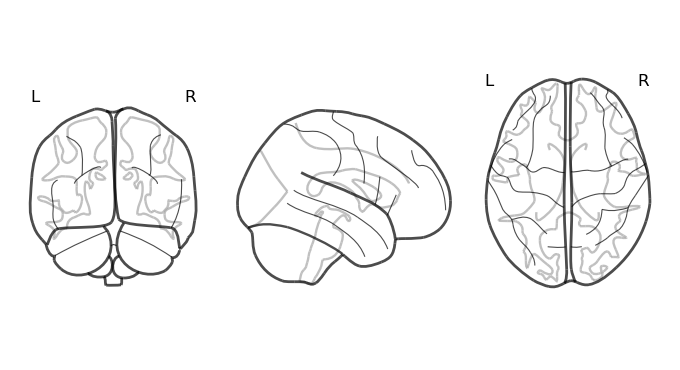

In [292]:
nn_brain = roi_to_brain(pd.Series(plot_significant_nodes_nn), expand_mask(mask_yeo_17))
display = plot_glass_brain(nn_brain.to_nifti())

# Save the figure
file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\Sig_Brain_Regions_All_Scenes_NN.png"
display.savefig(file_path_figure, dpi=300)

##### *Significant Nodes for AnnaK Model* 

In [260]:
significant_nodes_annak = [node for node in isrsa_annak_p if isrsa_annak_p[node] < 0.05]
significant_nodes_names_annak = [node_name_yeo_17_dict[node] for node in significant_nodes_annak] #change node_name_dict here, depending on which reference parcellation you are referring to!
significant_r_values_annak = [isrsa_annak_r[node] for node in significant_nodes_annak]
significant_p_values_annak = [isrsa_annak_p[node] for node in significant_nodes_annak]

print("Significant Nodes AnnaK Model:", significant_nodes_annak)
print("Significant Nodes Names AnnaK Model:", significant_nodes_names_annak)
print("Associated r-values AnnaK Model:", significant_r_values_annak)
print("Associated p-values AnnaK Model:", significant_p_values_annak)

# Create data frame
df_significant_annak = pd.DataFrame({
    'Node': significant_nodes_annak,
    'Node Name': significant_nodes_names_annak,
    'r-value': significant_r_values_annak,
    'p-value': significant_p_values_annak
})

# print in notebook
print(df_significant_annak)


Significant Nodes AnnaK Model: [2, 80, 85, 86, 100, 101, 102, 120, 147, 162, 168]
Significant Nodes Names AnnaK Model: ['LH_TempPar_Temp_3', 'LH_SomMotA_10', 'LH_SomMotA_6', 'LH_SomMotA_7', 'RH_TempPar_Temp_1', 'RH_TempPar_Temp_2', 'RH_TempPar_Temp_3', 'RH_DefaultA_PFCd_1', 'RH_SalVentAttnB_FrMed_1', 'RH_DorsAttnB_SPL_2', 'RH_DorsAttnA_TempOcc_3']
Associated r-values AnnaK Model: [np.float64(-0.23927255077576606), np.float64(-0.07719962804495299), np.float64(-0.11937343244091177), np.float64(-0.11847457478557058), np.float64(-0.19261446826156908), np.float64(-0.2040830150137141), np.float64(-0.1928341137237577), np.float64(-0.12128540578103261), np.float64(-0.1544028233529182), np.float64(-0.2168646571722775), np.float64(-0.2214280178804864)]
Associated p-values AnnaK Model: [np.float64(0.015796840631873626), np.float64(0.033593281343731254), np.float64(0.011597680463907219), np.float64(0.03079384123175365), np.float64(0.039192161567686463), np.float64(0.02539492101579684), np.float64(

*Plot the significant nodes - AnnaK Model*

In [262]:
n_nodes = 200
plot_significant_nodes_annak = {node: 0.8 if node in significant_nodes_annak else 0 for node in range(n_nodes)}
print(plot_significant_nodes_annak)  # To check the output

{0: 0, 1: 0, 2: 0.8, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0, 28: 0, 29: 0, 30: 0, 31: 0, 32: 0, 33: 0, 34: 0, 35: 0, 36: 0, 37: 0, 38: 0, 39: 0, 40: 0, 41: 0, 42: 0, 43: 0, 44: 0, 45: 0, 46: 0, 47: 0, 48: 0, 49: 0, 50: 0, 51: 0, 52: 0, 53: 0, 54: 0, 55: 0, 56: 0, 57: 0, 58: 0, 59: 0, 60: 0, 61: 0, 62: 0, 63: 0, 64: 0, 65: 0, 66: 0, 67: 0, 68: 0, 69: 0, 70: 0, 71: 0, 72: 0, 73: 0, 74: 0, 75: 0, 76: 0, 77: 0, 78: 0, 79: 0, 80: 0.8, 81: 0, 82: 0, 83: 0, 84: 0, 85: 0.8, 86: 0.8, 87: 0, 88: 0, 89: 0, 90: 0, 91: 0, 92: 0, 93: 0, 94: 0, 95: 0, 96: 0, 97: 0, 98: 0, 99: 0, 100: 0.8, 101: 0.8, 102: 0.8, 103: 0, 104: 0, 105: 0, 106: 0, 107: 0, 108: 0, 109: 0, 110: 0, 111: 0, 112: 0, 113: 0, 114: 0, 115: 0, 116: 0, 117: 0, 118: 0, 119: 0, 120: 0.8, 121: 0, 122: 0, 123: 0, 124: 0, 125: 0, 126: 0, 127: 0, 128: 0, 129: 0, 130: 0, 131: 0, 132: 0, 133: 0, 134: 0, 135: 0, 136: 

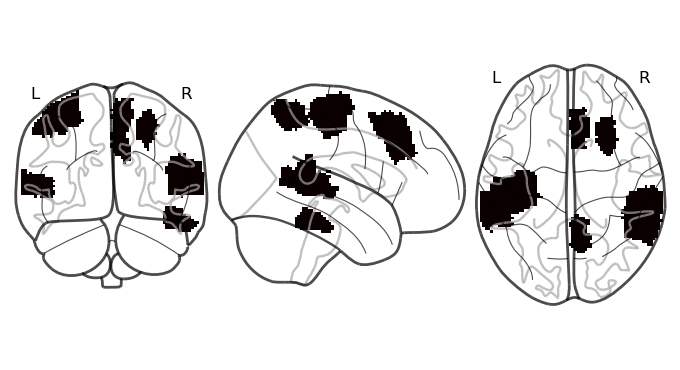

In [264]:
annak_brain = roi_to_brain(pd.Series(plot_significant_nodes_annak), expand_mask(mask_yeo_17))
display = plot_glass_brain(annak_brain.to_nifti())

# Save the figure
file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\Sig_Brain_Regions_All_Scenes_AnnaK.png"
display.savefig(file_path_figure, dpi=300)

##### *Significant Nodes for AnnaK Reversed Model* 

In [270]:
significant_nodes_annak_reversed = [node for node in isrsa_annak_reversed_p if isrsa_annak_reversed_p[node] < 0.05]
significant_nodes_names_annak_reversed = [node_name_yeo_17_dict[node] for node in significant_nodes_annak_reversed]
significant_r_values_annak_reversed = [isrsa_annak_reversed_r[node] for node in significant_nodes_annak_reversed]
significant_p_values_annak_reversed = [isrsa_annak_reversed_p[node] for node in significant_nodes_annak_reversed]

print("Significant Nodes AnnaK Reversed Model:", significant_nodes_annak_reversed)
print("Significant Nodes Names AnnaK ReversedModel:", significant_nodes_names_annak_reversed)
print("Associated r-values AnnaK Reversed Model:", significant_r_values_annak_reversed)
print("Associated p-values AnnaK Reversed Model:", significant_p_values_annak_reversed)

# Create data frame
df_significant_annak_reversed = pd.DataFrame({
    'Node': significant_nodes_annak_reversed,
    'Node Name': significant_nodes_names_annak_reversed,
    'r-value': significant_r_values_annak_reversed,
    'p-value': significant_p_values_annak_reversed
})

# print in notebook
print(df_significant_annak_reversed)

Significant Nodes AnnaK Reversed Model: [2, 80, 85, 86, 88, 100, 101, 107, 120, 147, 162, 168]
Significant Nodes Names AnnaK ReversedModel: ['LH_TempPar_Temp_3', 'LH_SomMotA_10', 'LH_SomMotA_6', 'LH_SomMotA_7', 'LH_SomMotA_9', 'RH_TempPar_Temp_1', 'RH_TempPar_Temp_2', 'RH_DefaultA_IPL_1', 'RH_DefaultA_PFCd_1', 'RH_SalVentAttnB_FrMed_1', 'RH_DorsAttnB_SPL_2', 'RH_DorsAttnA_TempOcc_3']
Associated r-values AnnaK Reversed Model: [np.float64(0.23927255077576606), np.float64(0.07719962804495299), np.float64(0.11937343244091177), np.float64(0.11847457478557058), np.float64(0.08866913170925611), np.float64(0.19261446826156908), np.float64(0.2040830150137141), np.float64(0.15592693782378383), np.float64(0.12128540578103261), np.float64(0.1544028233529182), np.float64(0.2168646571722775), np.float64(0.2214280178804864)]
Associated p-values AnnaK Reversed Model: [np.float64(0.013797240551889621), np.float64(0.03519296140771846), np.float64(0.008798240351929614), np.float64(0.027794441111777646), 

In [272]:
n_nodes = 200
plot_significant_nodes_annak_reversed = {node: 0.8 if node in significant_nodes_annak_reversed else 0 for node in range(n_nodes)}
print(plot_significant_nodes_annak_reversed)  # To check the output

{0: 0, 1: 0, 2: 0.8, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0, 28: 0, 29: 0, 30: 0, 31: 0, 32: 0, 33: 0, 34: 0, 35: 0, 36: 0, 37: 0, 38: 0, 39: 0, 40: 0, 41: 0, 42: 0, 43: 0, 44: 0, 45: 0, 46: 0, 47: 0, 48: 0, 49: 0, 50: 0, 51: 0, 52: 0, 53: 0, 54: 0, 55: 0, 56: 0, 57: 0, 58: 0, 59: 0, 60: 0, 61: 0, 62: 0, 63: 0, 64: 0, 65: 0, 66: 0, 67: 0, 68: 0, 69: 0, 70: 0, 71: 0, 72: 0, 73: 0, 74: 0, 75: 0, 76: 0, 77: 0, 78: 0, 79: 0, 80: 0.8, 81: 0, 82: 0, 83: 0, 84: 0, 85: 0.8, 86: 0.8, 87: 0, 88: 0.8, 89: 0, 90: 0, 91: 0, 92: 0, 93: 0, 94: 0, 95: 0, 96: 0, 97: 0, 98: 0, 99: 0, 100: 0.8, 101: 0.8, 102: 0, 103: 0, 104: 0, 105: 0, 106: 0, 107: 0.8, 108: 0, 109: 0, 110: 0, 111: 0, 112: 0, 113: 0, 114: 0, 115: 0, 116: 0, 117: 0, 118: 0, 119: 0, 120: 0.8, 121: 0, 122: 0, 123: 0, 124: 0, 125: 0, 126: 0, 127: 0, 128: 0, 129: 0, 130: 0, 131: 0, 132: 0, 133: 0, 134: 0, 135: 0, 136

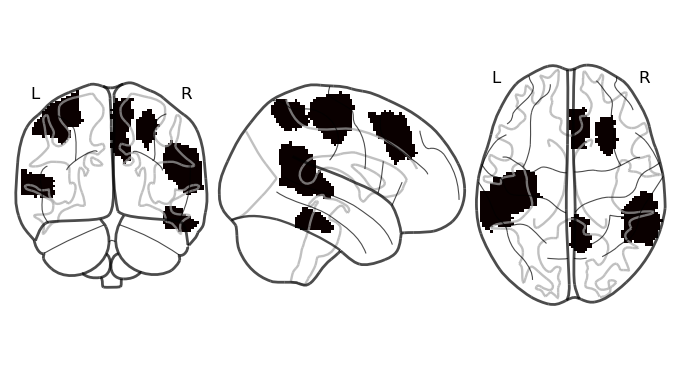

In [274]:
annak_reversed_brain = roi_to_brain(pd.Series(plot_significant_nodes_annak_reversed), expand_mask(mask_yeo_17))
display = plot_glass_brain(annak_reversed_brain.to_nifti())

# Save the figure
file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\Sig_Brain_Regions_All_Scenes_AnnaK_reversed.png"
display.savefig(file_path_figure, dpi=300)

##### *Significant Nodes for Gaussian Model*

In [278]:
significant_nodes_gauss = [node for node in isrsa_gauss_p if isrsa_gauss_p[node] < 0.05]
significant_nodes_names_gauss = [node_name_yeo_17_dict[node] for node in significant_nodes_gauss]
significant_r_values_gauss = [isrsa_gauss_r[node] for node in significant_nodes_gauss]
significant_p_values_gauss = [isrsa_gauss_p[node] for node in significant_nodes_gauss]

print("Significant Nodes Gaussian Model:", significant_nodes_gauss)
print("Significant Nodes Names Gaussian Model:", significant_nodes_names_gauss)
print("Associated r-values Gaussian Model:", significant_r_values_gauss)
print("Associated p-values Gaussian Model:", significant_p_values_gauss)

# Create data frame
df_significant_gauss = pd.DataFrame({
    'Node': significant_nodes_gauss,
    'Node Name': significant_nodes_names_gauss,
    'r-value': significant_r_values_gauss,
    'p-value': significant_p_values_gauss
})

# print in notebook
print(df_significant_gauss)

Significant Nodes Gaussian Model: [140]
Significant Nodes Names Gaussian Model: ['RH_ContA_PrCv_1']
Associated r-values Gaussian Model: [np.float64(0.10494457262809831)]
Associated p-values Gaussian Model: [np.float64(0.03739252149570086)]
   Node        Node Name   r-value   p-value
0   140  RH_ContA_PrCv_1  0.104945  0.037393


*Plot the significant nodes - Gaussian Model*

In [280]:
n_nodes = 200
plot_significant_nodes_gauss = {node: 0.8 if node in significant_nodes_gauss else 0 for node in range(n_nodes)}
print(plot_significant_nodes_gauss)  # To check the output

{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0, 28: 0, 29: 0, 30: 0, 31: 0, 32: 0, 33: 0, 34: 0, 35: 0, 36: 0, 37: 0, 38: 0, 39: 0, 40: 0, 41: 0, 42: 0, 43: 0, 44: 0, 45: 0, 46: 0, 47: 0, 48: 0, 49: 0, 50: 0, 51: 0, 52: 0, 53: 0, 54: 0, 55: 0, 56: 0, 57: 0, 58: 0, 59: 0, 60: 0, 61: 0, 62: 0, 63: 0, 64: 0, 65: 0, 66: 0, 67: 0, 68: 0, 69: 0, 70: 0, 71: 0, 72: 0, 73: 0, 74: 0, 75: 0, 76: 0, 77: 0, 78: 0, 79: 0, 80: 0, 81: 0, 82: 0, 83: 0, 84: 0, 85: 0, 86: 0, 87: 0, 88: 0, 89: 0, 90: 0, 91: 0, 92: 0, 93: 0, 94: 0, 95: 0, 96: 0, 97: 0, 98: 0, 99: 0, 100: 0, 101: 0, 102: 0, 103: 0, 104: 0, 105: 0, 106: 0, 107: 0, 108: 0, 109: 0, 110: 0, 111: 0, 112: 0, 113: 0, 114: 0, 115: 0, 116: 0, 117: 0, 118: 0, 119: 0, 120: 0, 121: 0, 122: 0, 123: 0, 124: 0, 125: 0, 126: 0, 127: 0, 128: 0, 129: 0, 130: 0, 131: 0, 132: 0, 133: 0, 134: 0, 135: 0, 136: 0, 137: 0, 138: 

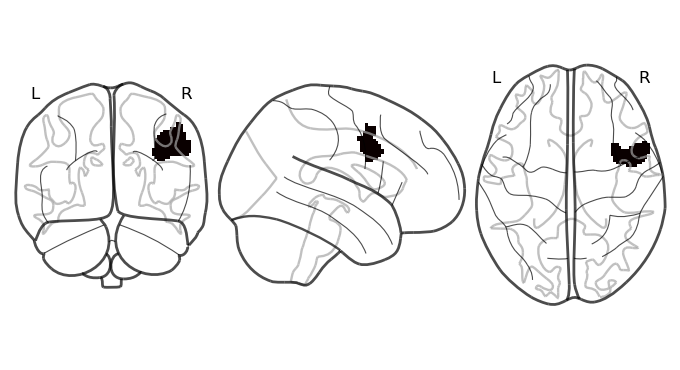

In [282]:
gauss_brain = roi_to_brain(pd.Series(plot_significant_nodes_gauss), expand_mask(mask_yeo_17))
display = plot_glass_brain(gauss_brain.to_nifti())

# Save the figure
file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Figures\IS-RSA All Scenes\Sig_Brain_Regions_All_Scenes_Gauss.png"
display.savefig(file_path_figure, dpi=300)

##### *FDR correction*

In [286]:
fdr_thr_nn = fdr(pd.Series(isrsa_nn_p).values)
print(f'FDR Threshold NN Model: {fdr_thr_nn}')

fdr_thr_annak = fdr(pd.Series(isrsa_annak_p).values)
print(f'FDR Threshold AnnaK Model: {fdr_thr_annak}')

fdr_thr_annak_reversed = fdr(pd.Series(isrsa_annak_reversed_p).values)
print(f'FDR Threshold AnnaK Model: {fdr_thr_annak}')

fdr_thr_gauss = fdr(pd.Series(isrsa_gauss_p).values)
print(f'FDR Threshold Gaussian Model: {fdr_thr_gauss}')

FDR Threshold NN Model: -1
FDR Threshold AnnaK Model: -1
FDR Threshold AnnaK Model: -1
FDR Threshold Gaussian Model: -1


*--> -1 means that no Nodes are significant after FDR Correction*